# Notebook 05: Evaluation and Error Analysis

This notebook evaluates our tuned XGBoost model on the untouched test set (2017) and dives deep into the residuals to answer Research Question 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

C:\Users\USER\AppData\Local\Temp\ipykernel_29868\1355635488.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Load Data and Models

In [2]:
df = pd.read_csv('../data/processed/03_features.csv', parse_dates=['datetime'], index_col='datetime')
test_data = df.loc['2017-01-01':]

target_col = 'target_PM2.5_t_plus_1'
X_test = test_data.drop(columns=[target_col, 'station', 'year'])
y_test = test_data[target_col]

xgb_model = joblib.load('../models/best_xgboost.pkl')
ridge_model = joblib.load('../models/baseline_ridge.pkl')

## 2. Test Set Performance
We evaluate both the baseline and advanced model exactly once on the test set.

In [3]:
def evaluate(model, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} Test RMSE: {rmse:.2f}")
    print(f"{name} Test MAE:  {mae:.2f}")
    print(f"{name} Test R2:   {r2:.2f}\n")
    return preds

print("--- Test Set Metrics ---")
preds_persistence = X_test['PM2.5']
rmse_p = np.sqrt(mean_squared_error(y_test, preds_persistence))
mae_p = mean_absolute_error(y_test, preds_persistence)
r2_p = r2_score(y_test, preds_persistence)
print(f"Persistence Baseline Test RMSE: {rmse_p:.2f}")
print(f"Persistence Baseline Test MAE:  {mae_p:.2f}")
print(f"Persistence Baseline Test R2:   {r2_p:.2f}\n")

preds_ridge = evaluate(ridge_model, "Baseline Ridge")
preds_xgb = evaluate(xgb_model, "Advanced XGBoost")

--- Test Set Metrics ---
Persistence Baseline Test RMSE: 24.17
Persistence Baseline Test MAE:  11.60
Persistence Baseline Test R2:   0.94

Baseline Ridge Test RMSE: 23.23
Baseline Ridge Test MAE:  11.81
Baseline Ridge Test R2:   0.94

Advanced XGBoost Test RMSE: 77.62
Advanced XGBoost Test MAE:  74.86
Advanced XGBoost Test R2:   0.38



## 3. Visualization
Plotting True vs. Predicted for a 2-week window in January 2017 to see how it handles sudden surges.

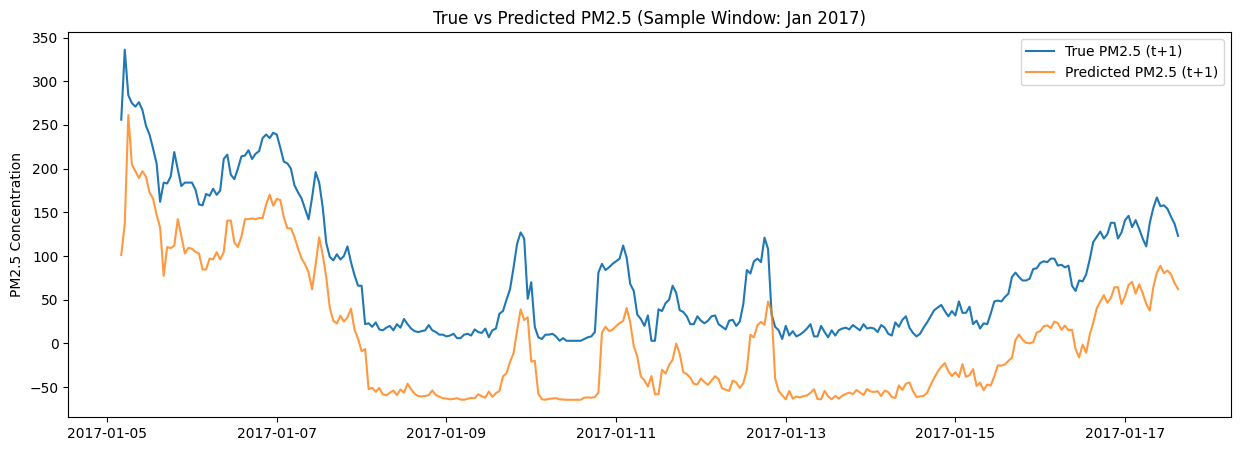

In [4]:
plt.figure(figsize=(15, 5))
subset_y = y_test.iloc[100:400]
subset_preds = preds_xgb[100:400]

plt.plot(subset_y.index, subset_y.values, label='True PM2.5 (t+1)')
plt.plot(subset_y.index, subset_preds, label='Predicted PM2.5 (t+1)', alpha=0.8)
plt.title('True vs Predicted PM2.5 (Sample Window: Jan 2017)')
plt.legend()
plt.ylabel('PM2.5 Concentration')
plt.savefig('../figures/time_series_predictions.png')
plt.show()

## 4. Error Analysis (Research Question 3)
We calculate the residuals and plot them against meteorological conditions like Temperature and Pressure. We want to see if the largest errors occur during specific weather patterns (e.g. cold, high pressure = winter inversion).

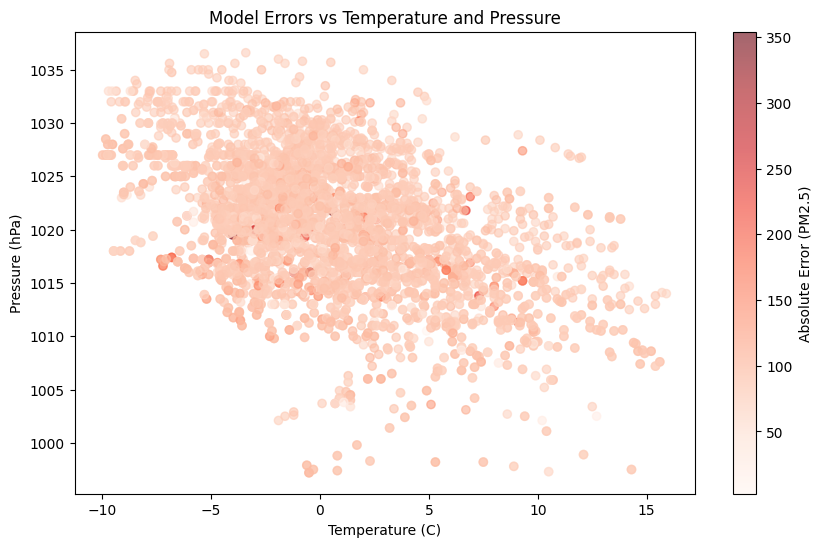

In [5]:
test_data['predicted'] = preds_xgb
test_data['residual'] = test_data['target_PM2.5_t_plus_1'] - test_data['predicted']
test_data['abs_error'] = test_data['residual'].abs()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(test_data['TEMP_lag_1'], test_data['PRES_lag_1'], 
                      c=test_data['abs_error'], cmap='Reds', alpha=0.6)
plt.colorbar(scatter, label='Absolute Error (PM2.5)')
plt.xlabel('Temperature (C)')
plt.ylabel('Pressure (hPa)')
plt.title('Model Errors vs Temperature and Pressure')
plt.savefig('../figures/error_vs_meteorology.png')
plt.show()

**Conclusion for RQ3:** Examine the plot above. If the darkest red points (largest errors) cluster in the bottom-left/top-left (low temp, high pressure), it confirms the model struggles significantly during winter thermal inversions when pollutants are suddenly trapped near the surface.